# Stage 05 — Regression (RQ1)

**Owner:** Sandesh Shahi (Analysis Lead)

**Research question.** *To what extent can industry sector, employer size, and policy adoption predict the proportion of women in management positions?*

**Model.** Multiple Linear Regression (scikit-learn `LinearRegression`), as justified in Assessment 1 §4.2 — the response is continuous in [0, 1] and linear regression quantifies the individual and combined effects of explanatory variables while supporting easy coefficient interpretation.

**Evaluation.** 80/20 train/test split; metrics MAE, RMSE, R², Adjusted R² (justified in `src/evaluation.py`).

**Assumption checks.** Linearity (scatter + residual pattern), normality of residuals (Q-Q plot), homoscedasticity (residuals vs fitted), no severe multicollinearity (already checked in notebook 04 via VIF).

**Inputs.** Checkpoints from notebook 03.

**Outputs.**
- `data/processed/checkpoints/05_ols_model.pkl`
- `data/processed/checkpoints/05_reg_metrics.json`
- `outputs/figures/rq1_*.png`

## 1. Setup and load checkpoints

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import config, regression, evaluation, visualisation
from src.utils import save_checkpoint

pd.set_option("display.max_columns", 30)

def _load(name):
    p = config.CHECKPOINT_DIR / name
    return pd.read_parquet(p) if p.exists() else pd.read_csv(p.with_suffix('.csv'))

X = _load("03_X.parquet")
y_reg = _load("03_y_reg.parquet").iloc[:, 0]
feature_names = json.load(open(config.CHECKPOINT_DIR / "03_feature_names.json"))
print("X:", X.shape, "| y_reg:", y_reg.shape)

X: (7971, 24) | y_reg: (7971,)


## 2. Fit OLS with an 80/20 split

In [2]:
reg_res = regression.fit_linear_regression(X, y_reg)
print(f"Train: {len(reg_res.X_train):,}   Test: {len(reg_res.X_test):,}   Features: {X.shape[1]}")
print("Intercept:", round(reg_res.model.intercept_, 4))

# Top coefficients by magnitude
coefs = (
    pd.DataFrame({"feature": feature_names, "coef": reg_res.model.coef_})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
)
coefs.head(15).round(4)

21:45:26 | INFO    | src.regression | OLS fitted: 6376 train / 1595 test samples, 24 features
Train: 6,376   Test: 1,595   Features: 24
Intercept: 0.4409


,feature,coef
9,div_Construction,-0.3218
16,div_Mining,-0.3057
15,div_Manufacturing,-0.2414
13,div_Health Care and Social Assistance,0.2404
11,"div_Electricity, Gas, Water and Waste Services",-0.2272
7,"div_Agriculture, Forestry and Fishing",-0.2155
22,"div_Transport, Postal and Warehousing",-0.2065
19,div_Public Administration and Safety,-0.1956
23,div_Wholesale Trade,-0.1514
20,"div_Rental, Hiring and Real Estate Services",-0.1244


## 3. Evaluation metrics (test set)

- **MAE** — average absolute error, robust to outliers, on the same 0–1 scale as the target.
- **RMSE** — penalises large errors more; informative for a bounded target.
- **R²** — share of variance explained.
- **Adjusted R²** — penalises adding predictors, so we don't fool ourselves with a big one-hot block.

In [3]:
reg_metrics = evaluation.regression_metrics(
    reg_res.y_test.values, reg_res.y_pred_test, n_features=X.shape[1]
)
print("RQ1 test-set metrics:")
for k, v in reg_metrics.items():
    print(f"  {k:7s} = {v:.4f}")

RQ1 test-set metrics:
  MAE     = 0.1428
  RMSE    = 0.1836
  R2      = 0.4596
  Adj_R2  = 0.4513


## 4. Assumption diagnostics

Residuals vs fitted checks linearity + homoscedasticity; the Q-Q plot checks normality of residuals.

21:45:27 | INFO    | src.regression | Saved regression diagnostic plots.
residuals_vs_fitted


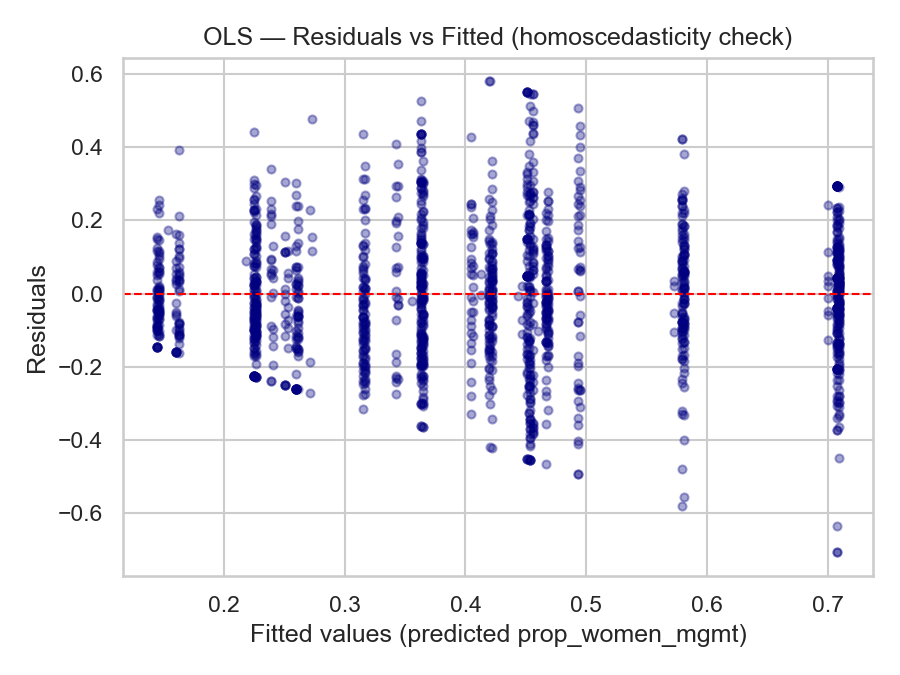

qq_plot


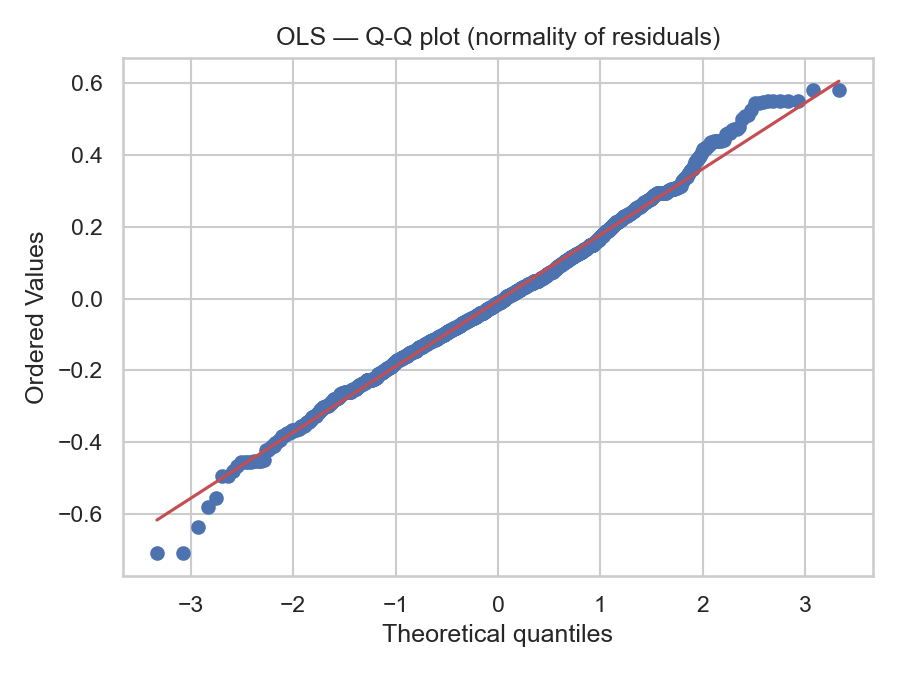

In [4]:
diag_paths = regression.diagnostics(reg_res)
for name, p in diag_paths.items():
    print(name)
    display(Image(str(p)))

## 5. Presentation figures

21:45:27 | INFO    | src.visualisation | Saved rq1_coefficients.png
21:45:27 | INFO    | src.visualisation | Saved rq1_pred_vs_actual.png


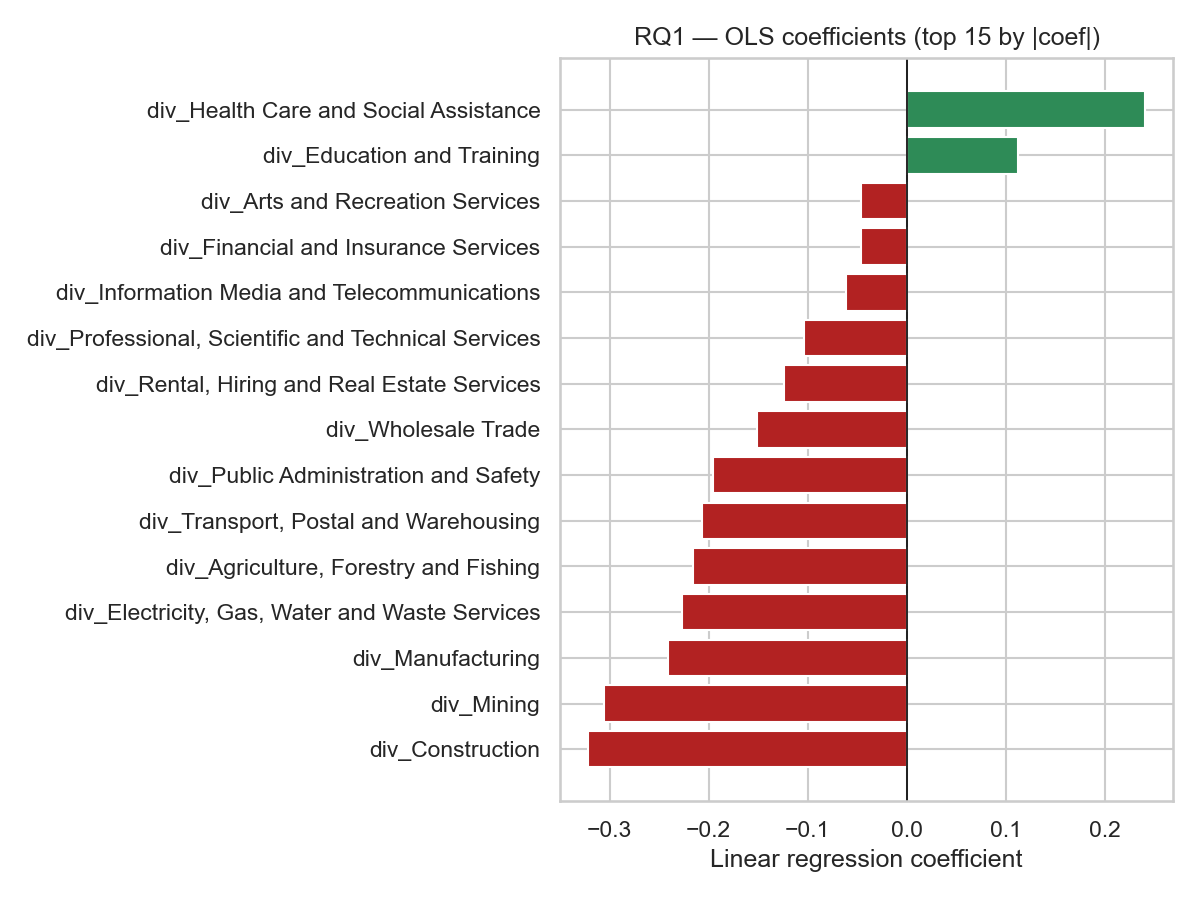

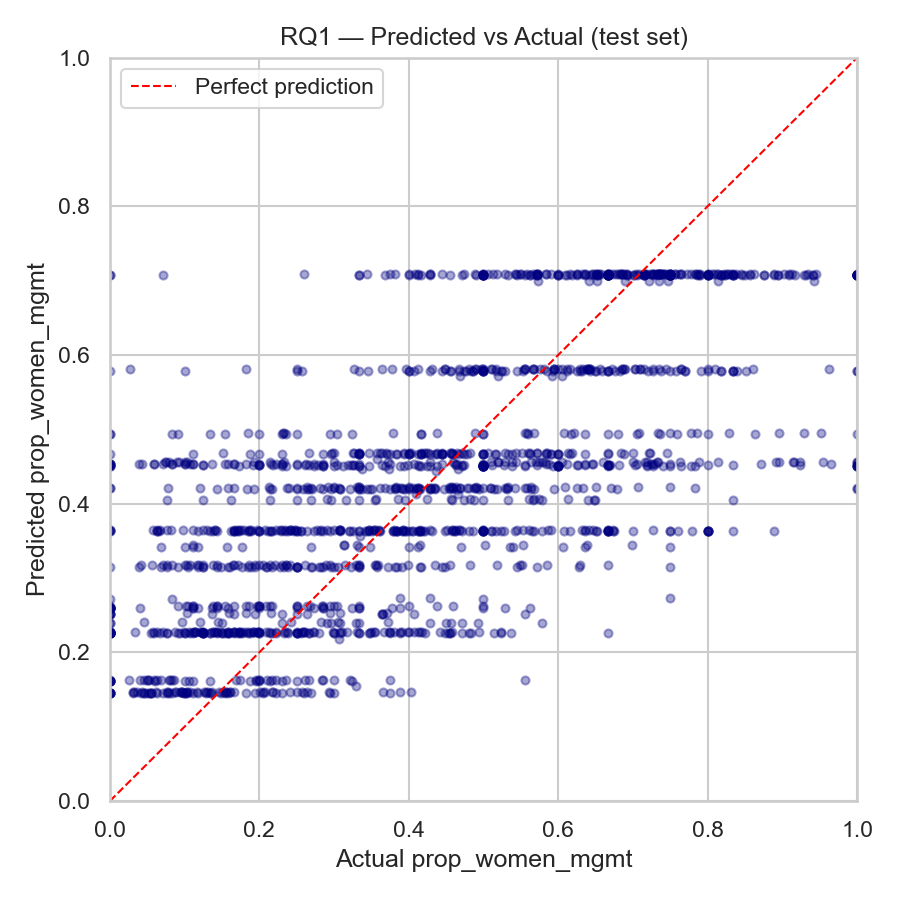

In [5]:
p1 = visualisation.plot_regression_coefficients(reg_res.model, feature_names)
p2 = visualisation.plot_predicted_vs_actual(reg_res.y_test.values, reg_res.y_pred_test)
display(Image(str(p1)))
display(Image(str(p2)))

## 6. Checkpoint

In [6]:
save_checkpoint(reg_res.model, config.CHECKPOINT_DIR / "05_ols_model.pkl")
with open(config.CHECKPOINT_DIR / "05_reg_metrics.json", "w") as f:
    json.dump(reg_metrics, f, indent=2)
print("Saved OLS model + metrics.")

Saved OLS model + metrics.


## Interpretation for the slide deck

- Top positive coefficients → features that **increase** predicted women-in-management.
- Top negative coefficients → features that **decrease** it.
- Adjusted R² tells the audience how much variance across ~12k employers our model actually explains.
- Residual diagnostics should be discussed honestly: if they look non-linear or heteroscedastic, we flag it as a model limitation on the limitations slide.

**Next:** `06_classification.ipynb` — RQ2 Random Forest vs Naive Bayes.